# EXPERIMENT: COMPARISON OF OPTIMIZATION ALGORITHMS
# Aim:
To implement and compare different optimization algorithms on a Deep Neural Network and
analyze their convergence behavior.
# Dataset: MNIST
# Optimizers: SGD, RMSprop, Adam, Adagrad


In [ ]:
# Import libraries & load MNIST dataset
import tensorflow as tf
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = \
tf.keras.datasets.mnist.load_data()

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


In [ ]:
# Convert data to float32 and normalize
# This avoids the MemoryError caused by float64
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Data preprocessing completed")

Data preprocessing completed


In [ ]:
# Create neural network
def create_model():

    model = tf.keras.Sequential([

    # Input layer
    tf.keras.layers.Flatten(input_shape=(28, 28)),

    # Hidden layer 1
    tf.keras.layers.Dense(128, activation="relu"),

    # Hidden layer 2
    tf.keras.layers.Dense(64, activation="relu"),

    # Output layer
    tf.keras.layers.Dense(10, activation="softmax")
    ])

    return model

In [ ]:
# Define optimizers
optimizers = {

"SGD": tf.keras.optimizers.SGD(
learning_rate=0.01
),

"RMSprop": tf.keras.optimizers.RMSprop(
learning_rate=0.001
),

"Adam": tf.keras.optimizers.Adam(
learning_rate=0.001
),

"Adagrad": tf.keras.optimizers.Adagrad(
learning_rate=0.01
)
}

In [ ]:
# Store training results
history = {}

In [ ]:
# Train the model with each optimizer
for name, optimizer in optimizers.items():

    print("\n================================")
    print("Training using:", name)
    print("================================")

    # Create a new model
    model = create_model()

    # Compile the model

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Train the model
    h = model.fit(
        x_train,
        y_train,
        epochs=5,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    # Store history
    history[name] = h

    # Evaluate model
    test_loss, test_accuracy = model.evaluate(
        x_test,
        y_test,
        verbose=0
    )

    print("Test Loss :", test_loss)
    print("Test Accuracy :", test_accuracy)


Training using: SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6317 - loss: 1.3943 - val_accuracy: 0.8375 - val_loss: 0.7066
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8526 - loss: 0.5812 - val_accuracy: 0.8850 - val_loss: 0.4420
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8841 - loss: 0.4309 - val_accuracy: 0.9003 - val_loss: 0.3657
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8966 - loss: 0.3732 - val_accuracy: 0.9082 - val_loss: 0.3297
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9042 - loss: 0.3407 - val_accuracy: 0.9142 - val_loss: 0.3061
Test Loss : 0.30938446521759033
Test Accuracy : 0.9121000170707703

Training using: RMSprop
Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9020 - loss: 0.3469 - val_accuracy: 0.9499 - val_loss: 0.1775
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9527 - loss: 0.1566 - val_accuracy: 0.9647 - val_loss: 0.1305
Epoch 3/5
375/375 ━

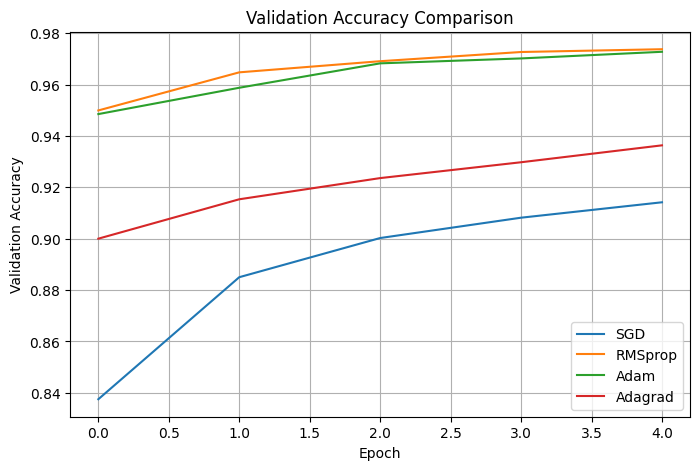

In [ ]:
# Validation accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for name, h in history.items():
    plt.plot(
        h.history["val_accuracy"],
        label=name
    )

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

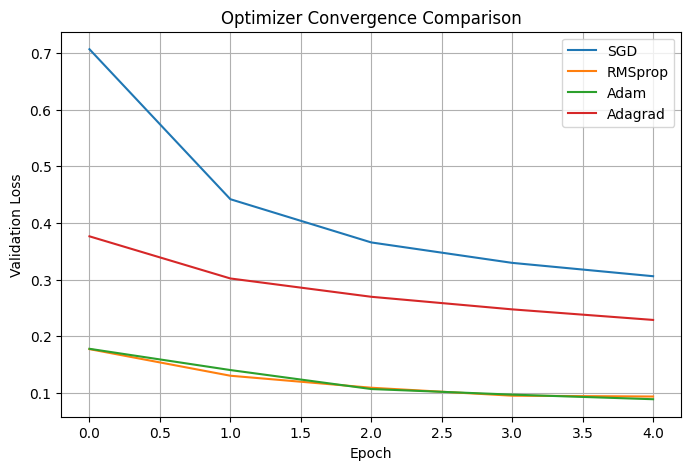

In [ ]:
# Validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for name, h in history.items():
    plt.plot(
        h.history["val_loss"],
        label=name
    )

plt.title("Optimizer Convergence Comparison")
plt.xlabel("Epoch")

plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Display best validation accuracy
print("\n================================")
print("BEST VALIDATION ACCURACY")
print("================================")

for name, h in history.items():
    best_accuracy = max(
        h.history["val_accuracy"]
    )

    print(
        name,
        ":",
        round(best_accuracy, 4)
    )

print("\nExperiment completed successfully.")


BEST VALIDATION ACCURACY
SGD : 0.9142
RMSprop : 0.9737
Adam : 0.9728
Adagrad : 0.9363

Experiment completed successfully.


## Experiment Takeaways

This experiment compared four optimization algorithms (SGD, RMSprop, Adam, Adagrad) on a Deep Neural Network trained on the MNIST dataset.

**Key Observations:**

*   **Performance:** RMSprop and Adam consistently achieved the highest validation accuracies and the lowest validation losses, indicating superior convergence and generalization for this task. They both reached over 97% validation accuracy.
*   **Convergence Speed:** RMSprop and Adam demonstrated faster convergence, quickly reaching a high performance plateau within the first few epochs.
*   **SGD & Adagrad:** SGD showed a slower and less optimal convergence path, eventually reaching around 91% validation accuracy. Adagrad performed better than SGD but lagged behind RMSprop and Adam, achieving approximately 93.6% validation accuracy.

In conclusion, for this specific neural network architecture and dataset, **RMSprop and Adam proved to be the most effective optimizers**, exhibiting both rapid convergence and high final accuracy, which is crucial for efficient model training.